In [7]:
import pickle
import matplotlib.pyplot as plt

In [12]:
ROOT_DIR = "/scratch4/workspace/ppruthi_umass_edu-CG/task_based_compositional_generalization"
path = f"{ROOT_DIR}/models/eval/uniform/fixed/nalph_26_seqlen_6_fnlen_6_taskmaxlen_6/step_by_step"


# Position wise coverage violations

In [3]:
import os
seeds = [0, 10, 20, 30, 40]
pos_list = ["abs", "rel_global"]
# strategies = ["coverage_6_0_0", "coverage_6_0_1", "coverage_6_0_2", "coverage_6_0_3", "coverage_6_0_4", "coverage_6_0_5", 
#               "coverage_6_1_0", "coverage_6_1_1", "coverage_6_1_2", "coverage_6_1_3", "coverage_6_1_4", "coverage_6_1_5", 
#               "coverage_6_2_0", "coverage_6_2_1", "coverage_6_2_2", "coverage_6_2_3", "coverage_6_2_4", "coverage_6_2_5", 
#               "coverage_6_3_0", "coverage_6_3_1", "coverage_6_3_2", "coverage_6_3_3", "coverage_6_3_4", "coverage_6_3_5", 
#               "coverage_6_4_0", "coverage_6_4_1", "coverage_6_4_2", "coverage_6_4_3", "coverage_6_4_4", "coverage_6_4_5", 
#               "coverage_6_5_0", "coverage_6_5_1", "coverage_6_5_2", "coverage_6_5_3", "coverage_6_5_4", "coverage_6_5_5"]
strategies = ["all_6"]
count = 0
results = {}
for pos in pos_list:
    results[pos] = {}
    for strategy in strategies:
        results[pos][strategy] = []
        for seed in seeds:
            train_strategy_name = f"train_{strategy}"
            eval_strategy_name = f"eval_{strategy}"
            results_path = f"{path}/{train_strategy_name}/{eval_strategy_name}/{pos}/nh6_nl3/seed_{seed}/accs.pkl"
            
            try:
                metrics = pickle.load(open(results_path, 'rb'))
                results[pos][strategy].append(metrics["test"].sharp_accuracy)
            except:
                count += 1
                print(f"Error loading results from {results_path}")
                results[pos][strategy].append(0)
print(count)
            # else:
            #     results[pos][strategy].append(0)

            
                
                
            # else:
            #     train_strategy_name = f"train_coverage_{strategy}"
            #     eval_strategy_name = f"eval_coverage_{strategy}"
            #     results_path = f"{path}/{train_strategy_name}/{eval_strategy_name}/{pos}/nh6_nl3/seed_{seed}/accs.pkl"
            #     metrics = pickle.load(open(results_path, 'rb'))
            #     results[pos][strategy].append(metrics["test"].sharp_accuracy)


/work/pi_jensen_umass_edu/ppruthi_umass_edu/.conda/envs/CG/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


0


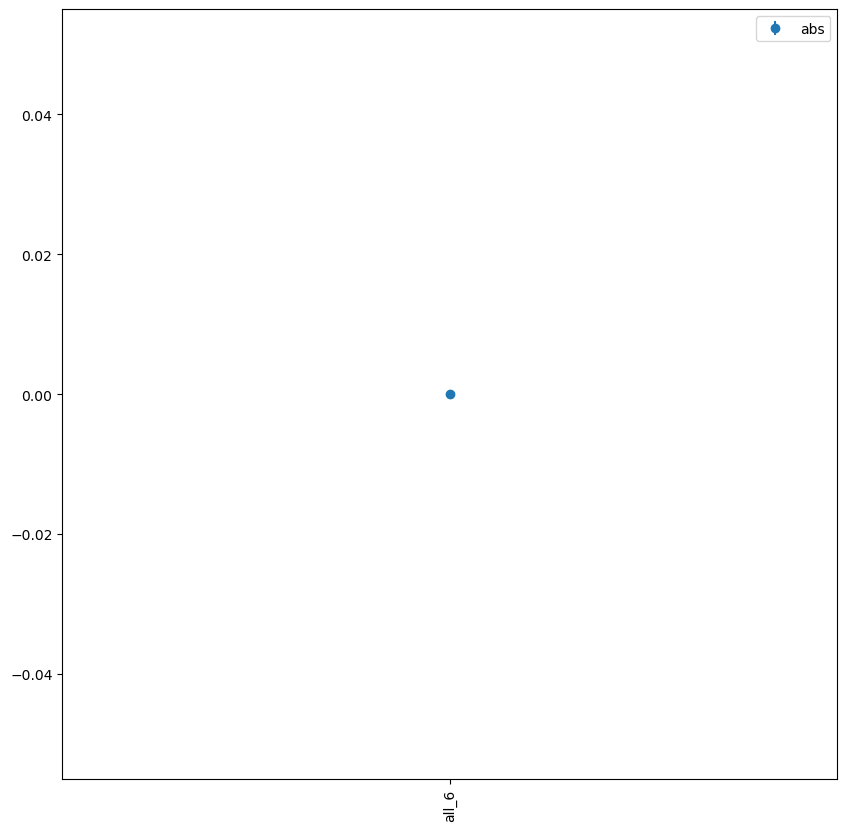

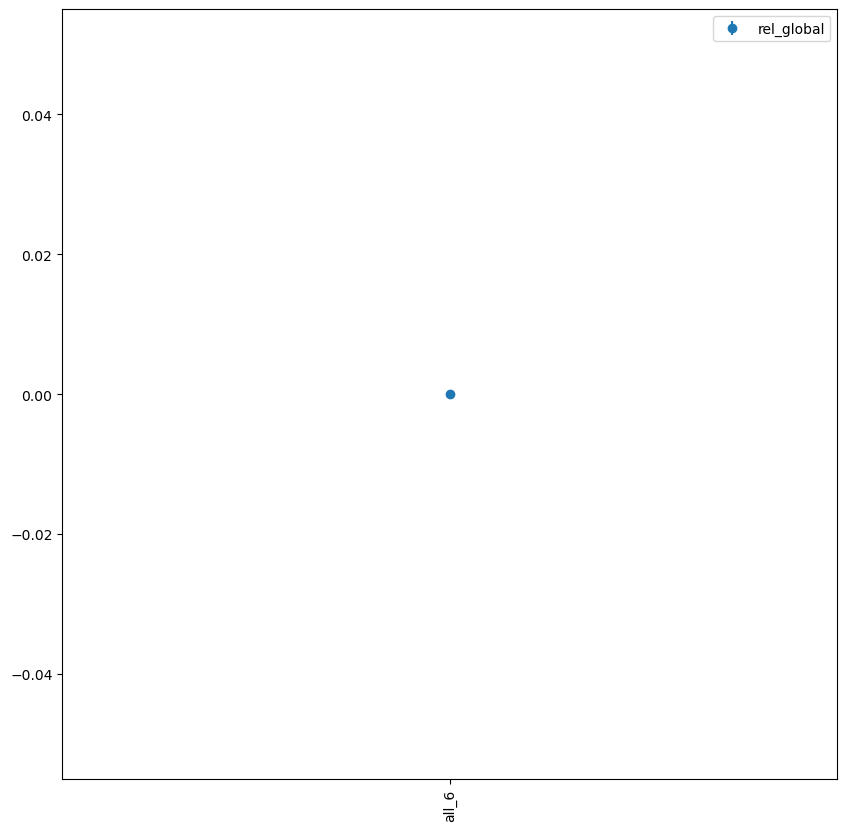

In [10]:
# find mean and std of results

import numpy as np

for pos in pos_list:
    x_values = []
    y_values = []
    y_std = []
    plt.figure(figsize=(10, 10))
    for strategy_index, strategy in enumerate(strategies):
        
        mean = np.mean(results[pos][strategy])
        # if mean < 0.9:
        # module_name = int(strategy.split("_")[2]) + 1   
        # pos_name = int(strategy.split("_")[3]) + 1
        # x_values.append(f"Mod. {module_name} Pos. {pos_name}")
        x_values.append(strategy)
        y_values.append(np.mean(results[pos][strategy]))
        y_std.append(np.std(results[pos][strategy]))
        # print(pos, strategy,b
        # results[pos][strategy])
        # print(pos, strategy, np.mean(results[pos][strategy]), np.std(results[pos][strategy]))
        # plot error bar
        # have vertical line after each 6 strategies
    #     if int(strategy.split("_")[3]) == 0 or int(strategy.split("_")[3]) == 5:
    #         plt.axvline(x=strategy_index, color='black', linestyle='--')
    # # 
    plt.errorbar(x_values, y_values, yerr=y_std, fmt='o', label=pos)
    # x-axis labels at 45 degree angle
    plt.xticks(rotation=90)
    plt.legend()
    plt.show()


In [11]:
y_values

[np.float64(0.0)]

In [11]:
(20*16)/(620*16)

0.03225806451612903

# Pair-wise coverage violations

In [13]:
import os
seeds = [0, 10, 20, 30, 40]
pos_list = ["abs", "rel_global"]
# nums = list(np.arange(0, 30))
nums = [0]
strategies = [f"reversepaircoverage_6_{i}" for i in nums ]

count = 0
results = {}
train_results = {}
train_heldout_results = {}
for pos in pos_list:
    results[pos] = {}
    train_results[pos] = {}
    train_heldout_results[pos] = {}
    for strategy in strategies:
        results[pos][strategy] = []
        train_results[pos][strategy] = []
        train_heldout_results[pos][strategy] = []
        for seed in seeds:
            train_strategy_name = f"train_{strategy}"
            eval_strategy_name = f"eval_{strategy}"
            results_path = f"{path}/{train_strategy_name}/{eval_strategy_name}/{pos}/nh6_nl3/seed_{seed}/accs.pkl"
            
            try:
                metrics = pickle.load(open(results_path, 'rb'))
                results[pos][strategy].append(metrics["test"].sharp_accuracy)
                
                print("Train accuracy: ", metrics["train"].sharp_accuracy)
                print("Train heldout accuracy: ", metrics["train_heldout"].sharp_accuracy)
                print("Test accuracy: ", metrics["test"].sharp_accuracy)
                train_results[pos][strategy].append(metrics["train"].sharp_accuracy)
                train_heldout_results[pos][strategy].append(metrics["train_heldout"].sharp_accuracy)
            except:
                count += 1
                print(f"Error loading results from {results_path}")
                results[pos][strategy].append(0)
print(count)
            # else:
            #     results[pos][strategy].append(0)

            
                
                
            # else:
            #     train_strategy_name = f"train_coverage_{strategy}"
            #     eval_strategy_name = f"eval_coverage_{strategy}"
            #     results_path = f"{path}/{train_strategy_name}/{eval_strategy_name}/{pos}/nh6_nl3/seed_{seed}/accs.pkl"
            #     metrics = pickle.load(open(results_path, 'rb'))
            #     results[pos][strategy].append(metrics["test"].sharp_accuracy)


Train accuracy:  0.999989926815033
Train heldout accuracy:  1.0
Test accuracy:  0.9997991919517517
Train accuracy:  0.9999999403953552
Train heldout accuracy:  1.0
Test accuracy:  1.0
Train accuracy:  0.9999799132347107
Train heldout accuracy:  1.0
Test accuracy:  0.9995984435081482
Train accuracy:  0.999989926815033
Train heldout accuracy:  0.9998958706855774
Test accuracy:  0.9248996376991272
Train accuracy:  0.9999497532844543
Train heldout accuracy:  0.99979168176651
Test accuracy:  1.0
Train accuracy:  0.9999999403953552
Train heldout accuracy:  1.0
Test accuracy:  1.0
Train accuracy:  0.9999999403953552
Train heldout accuracy:  1.0
Test accuracy:  1.0
Train accuracy:  0.9999999403953552
Train heldout accuracy:  1.0
Test accuracy:  1.0
Train accuracy:  0.9999999403953552
Train heldout accuracy:  1.0
Test accuracy:  0.9995984435081482
Train accuracy:  0.9999999403953552
Train heldout accuracy:  1.0
Test accuracy:  1.0
0


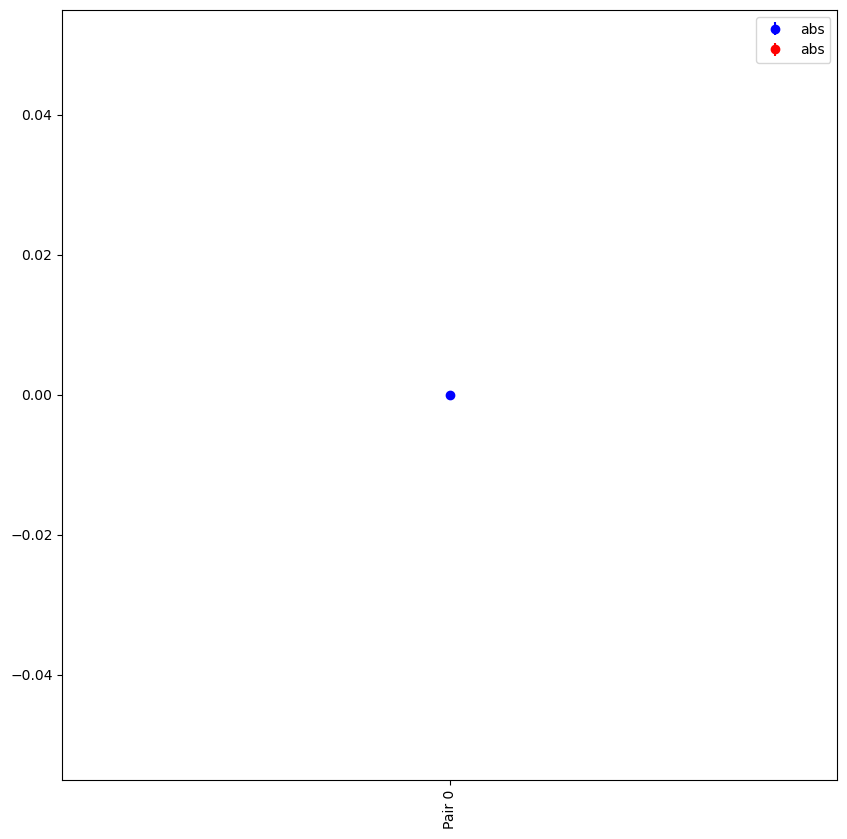

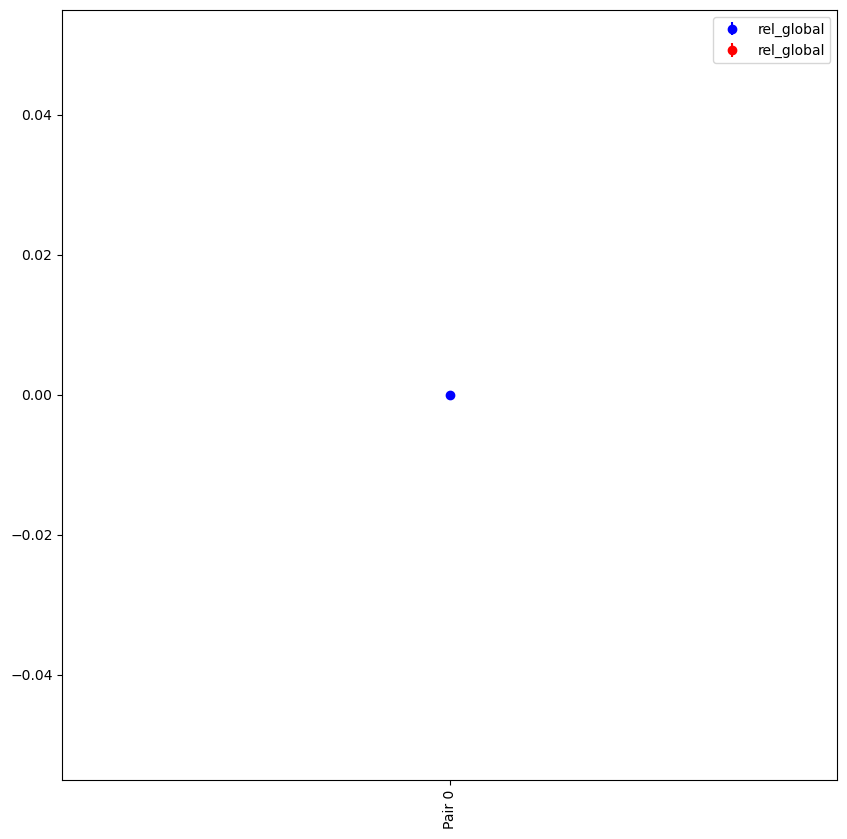

In [5]:
# find mean and std of results

import numpy as np

for pos in pos_list:
    x_values = []
    y_values = []
    y_std = []
    
    x_train_heldout = []
    y_train_heldout = []
    y_train_heldout_std = []
    plt.figure(figsize=(10, 10))
    for strategy_index, strategy in enumerate(strategies):
        
        mean = np.mean(results[pos][strategy])
        # if mean < 0.9:
        pair_number = int(strategy.split("_")[2])
        x_values.append(f"Pair {pair_number}")
        y_values.append(np.mean(results[pos][strategy]))
        y_std.append(np.std(results[pos][strategy]))
        # x_train_heldout.append(f"Pair {pair_number}")
        # y_train_heldout.append(np.mean(train_heldout_results[pos][strategy]))
        # y_train_heldout_std.append(np.std(train_heldout_results[pos][strategy]))
        # print(pos, strategy, results[pos][strategy])
        # print(pos, strategy, np.mean(results[pos][strategy]), np.std(results[pos][strategy]))
        # plot error bar
       
    plt.errorbar(x_values, y_values, yerr=y_std, fmt='o', label=pos, color='blue')
    plt.errorbar(x_train_heldout, y_train_heldout, yerr=y_train_heldout_std, fmt='o', label=pos, color='red')
    # x-axis labels at 45 degree angle
    plt.xticks(rotation=90)
    plt.legend()
    plt.show()


Marginal support for each module

In [ ]:
from collections import defaultdict
import numpy as np
path = "/scratch4/workspace/ppruthi_umass_edu-CG/task_based_compositional_generalization/data/uniform/fixed/nalph_26_seqlen_6_fnlen_6_taskmaxlen_6/step_by_step/paircoverage_6_0/train_step_by_step_corpus.npy"
train_data = np.load(path)
test_data = np.load(path.replace("train", "test"))

train_function_list = train_data[:, 1:7]
test_function_list = test_data[:, 1:7]

# get unique function lists
train_function_list = np.unique(train_function_list, axis=0)
test_function_list = np.unique(test_function_list, axis=0)

# now get distribution of each function at each position
# set default values to 0
train_function_distribution = {0: defaultdict(int), 1: defaultdict(int), 2: defaultdict(int), 3: defaultdict(int), 4: defaultdict(int), 5: defaultdict(int)}
test_function_distribution = {0: defaultdict(int), 1: defaultdict(int), 2: defaultdict(int), 3: defaultdict(int), 4: defaultdict(int), 5: defaultdict(int)}

for fn in train_function_list:
    for i in range(6):
        train_function_distribution[i][fn[i]] = train_function_distribution[i].get(fn[i], 0) + 1

for fn in test_function_list:
    for i in range(6):
        test_function_distribution[i][fn[i]] = test_function_distribution[i].get(fn[i], 0) + 1

train_function_distribution

{0: {np.int64(31): 24,
  np.int64(33): 24,
  np.int64(34): 24,
  np.int64(35): 24,
  np.int64(36): 4},
 1: {np.int64(32): 24,
  np.int64(31): 22,
  np.int64(34): 12,
  np.int64(35): 12,
  np.int64(36): 18,
  np.int64(33): 12},
 2: {np.int64(33): 14,
  np.int64(34): 14,
  np.int64(35): 14,
  np.int64(36): 18,
  np.int64(32): 22,
  np.int64(31): 18},
 3: {np.int64(34): 16,
  np.int64(35): 14,
  np.int64(36): 18,
  np.int64(33): 16,
  np.int64(32): 18,
  np.int64(31): 18},
 4: {np.int64(35): 16,
  np.int64(36): 18,
  np.int64(34): 15,
  np.int64(33): 15,
  np.int64(32): 18,
  np.int64(31): 18},
 5: {np.int64(36): 24,
  np.int64(35): 20,
  np.int64(34): 19,
  np.int64(33): 19,
  np.int64(32): 18}}

In [28]:
import sys
sys.path.append("/scratch4/workspace/ppruthi_umass_edu-CG/task_based_compositional_generalization/src")
from src.data.modules.randomFunctions import MapRandom

MapRandom.map_random(seed=1).mapping

{'a': 'e',
 'b': 's',
 'c': 'c',
 'd': 'i',
 'e': 'd',
 'f': 'p',
 'g': 'o',
 'h': 'u',
 'i': 'm',
 'j': 'g',
 'k': 'v',
 'l': 'h',
 'm': 'a',
 'n': 'q',
 'o': 'r',
 'p': 'j',
 'q': 'n',
 'r': 't',
 's': 'z',
 't': 'f',
 'u': 'b',
 'v': 'w',
 'w': 'k',
 'x': 'l',
 'y': 'y',
 'z': 'x'}

In [27]:
MapRandom.map_random(seed=3).mapping

{'a': 'h',
 'b': 's',
 'c': 'r',
 'd': 'e',
 'e': 'l',
 'f': 't',
 'g': 'p',
 'h': 'y',
 'i': 'c',
 'j': 'a',
 'k': 'u',
 'l': 'w',
 'm': 'i',
 'n': 'd',
 'o': 'm',
 'p': 'z',
 'q': 'n',
 'r': 'j',
 's': 'k',
 't': 'v',
 'u': 'f',
 'v': 'b',
 'w': 'o',
 'x': 'x',
 'y': 'q',
 'z': 'g'}